# Predicting the Sale Price of Bulldozers using Machine Learning
> The goal of the project is to predict the sale price of a particular piece of heavy equiment at auction based on it's usage, equipment type, and configuaration.  The data is sourced from auction result postings and includes information on usage and equipment configurations.


## Modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_log_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

### Building a custom Transformers for the pipeline for Preprocessing and preparing the data for modelling

In [2]:
# Create a pipeline that extracts year, month, day, DayOfWeek from the saledate column and then drop the saledate column
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extracts date components from saledate and drops the original.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if "saledate" in X.columns:
            X["saledate"] = pd.to_datetime(X["saledate"])
            X["saleYear"] = X["saledate"].dt.year
            X["saleMonth"] = X["saledate"].dt.month
            X["saleDayOfWeek"] = X["saledate"].dt.dayofweek
            X["saleDayOfYear"] = X["saledate"].dt.dayofyear
            X.drop("saledate", axis=1, inplace=True)

        return X

class TabularImputerAndEncoder(BaseEstimator, TransformerMixin):
    """
    Learns training medians and category mappings, then applies them to any raw dataset.
    """
    def __init__(self):
        self.training_medians_ = {}
        self.category_mappings_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Learn numeric medians
        for label, content in X.items():
            if pd.api.types.is_numeric_dtype(content):
                if pd.isnull(content).sum() > 0:
                    self.training_medians_[label] = content.median()

        # Learn categorical mappings
        for label, content in X.items():
            if not pd.api.types.is_numeric_dtype(content):
                content_cat = content.astype("category")
                self.category_mappings_[label] = content_cat.cat.categories
        return self

    def transform(self, X):
        X = X.copy()
        # Use a dictionary to collect new columns before joining to avoid fragmentation
        new_columns = {}

        # Process Numeric Columns
        for label, content in X.items():
            if pd.api.types.is_numeric_dtype(content):
                is_missing = pd.isnull(content)
                new_columns[label + "_is_missing"] = is_missing

                if label in self.training_medians_:
                    X[label] = content.fillna(self.training_medians_[label])

        # Process Categorical Columns
        for label, content in X.items():
            if not pd.api.types.is_numeric_dtype(content):
                new_columns[label + "_is_missing"] = pd.isnull(content)
                content_cat = content.astype("category")

                if label in self.category_mappings_:
                    encoded = pd.Categorical(content_cat, categories=self.category_mappings_[label]).codes + 1
                    X[label] = encoded
                else:
                    # Fallback for entirely new categories unseen in training
                    X[label] = pd.Categorical(content_cat).codes + 1

        # Concat all the missing indicator columns at once
        if new_columns:
            new_df = pd.DataFrame(new_columns, index=X.index)
            X = pd.concat([X, new_df], axis=1)

        return X

In [24]:
# Create the pipeline
bulldozer_pipeline = Pipeline([
    ("date_extractor", DateFeatureExtractor()),
    ("imputer_and_encoder", TabularImputerAndEncoder()),
    ("model", RandomForestRegressor(n_estimators=100,
                                    min_samples_leaf=3,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None,
                                    random_state=42))
])

In [25]:
# Load Raw Training data
df_train = pd.read_csv("data/bluebook-for-bulldozers/Train.csv", low_memory=False)
df_train

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401120,6333336,10500,1840702,21439,149,1.0,2005,NaN,NaN,11/2/2011 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
401121,6333337,11000,1830472,21439,149,1.0,2005,NaN,NaN,11/2/2011 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
401122,6333338,11500,1887659,21439,149,1.0,2005,NaN,NaN,11/2/2011 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
401123,6333341,9000,1903570,21435,149,2.0,2005,NaN,NaN,10/25/2011 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN


In [26]:
# Separate features and labels
X_train = df_train.drop("SalePrice", axis = 1)
y_train = df_train["SalePrice"]

In [27]:
X_train.shape, y_train.shape

((401125, 52), (401125,))

In [28]:
# FIT THE ENTIRE PIPELINE (Learns dates, medians, categories and trains the model)
print("Training pipeline...")
bulldozer_pipeline.fit(X_train, y_train)

Training pipeline...


,steps,"[('date_extractor', ...), ('imputer_and_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,14
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,0.5


In [27]:
bulldozer_pipeline.score(X_train, y_train)

0.9512741256122559

In [30]:
# Load Raw Validation Data
X_valid = pd.read_csv("data/bluebook-for-bulldozers/Valid.csv", low_memory=False)

# Predict directly on raw validation data
valid_preds = bulldozer_pipeline.predict(X_valid)
valid_preds

array([39039.75101221, 69523.78482925, 32409.75785392, ...,
       10040.04841496, 12502.56188436, 17500.66563563], shape=(11573,))

In [10]:
# Create an evaluation function
def evaluate_and_predict_valid(X_valid, y_valid, pipeline, output_csv_path="valid_predictions.csv"):
    """
    Evaluates the validation set against the solution set, calculates R2, MAE, and RMSLE, and generates the formatted prediction dataset.
    """

    # Keep a copy of SalesID for the final output
    sales_ids = X_valid["SalesID"].copy()

    # Generate predictions
    print("Generating predictions on validation set...")
    preds = pipeline.predict(X_valid)

    # Build a temporary dataframe to align predictions with true values by SalesID
    df_preds = pd.DataFrame({
        "SalesID": sales_ids,
        "SalePrice_pred": preds
    })

    # Merge with the solution dataframe on SalesID to ensure strict alignment
    merged_eval = df_preds.merge(y_valid, on="SalesID")
    y_true = merged_eval["SalePrice"]
    y_pred = merged_eval["SalePrice_pred"]

    # Calculate metrics (ensure no negative values exist for MSLE calculations)
    y_pred_clipped = np.clip(y_pred, 0, None)

    r2 = r2_score(y_true, y_pred_clipped)
    mae = mean_absolute_error(y_true, y_pred_clipped)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clipped))

    # print metrics
    print("\n--- Validation Metrics ---")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"RMSLE   : {rmsle:.4f}")

    # Generate and save the final predictions dataset format requested
    final_submission = pd.DataFrame({
        "SalesID": sales_ids,
        "SalePrice": preds
    })

    final_submission.to_csv(output_csv_path, index=False)
    print(f"\nPredictions successfully saved to '{output_csv_path}'")

    return final_submission, {"r2": r2, "mae": mae, "rmsle": rmsle}

In [37]:
submission_df, metrics = evaluate_and_predict_valid(
    X_valid = pd.read_csv("data/bluebook-for-bulldozers/Valid.csv", low_memory=False),
    y_valid = pd.read_csv("data/bluebook-for-bulldozers/ValidSolution.csv", low_memory=False),
    pipeline = bulldozer_pipeline,
    output_csv_path = "valid_predictions.csv"
)

# Preview the first few rows of the generated prediction dataset
print("\nPreview of final prediction dataset:")
print(submission_df.head())

Generating predictions on validation set...

--- Validation Metrics ---
R2 Score: 0.8827
MAE     : 5895.7777
RMSLE   : 0.2431

Predictions successfully saved to 'valid_predictions.csv'

Preview of final prediction dataset:
   SalesID     SalePrice
0  1222837  39039.751012
1  1222839  69523.784829
2  1222841  32409.757854
3  1222843  16223.310272
4  1222845  41386.787766


## Trying out some other models to see if our result can be improved

#### LightGBM

In [49]:
# import sys
# import subprocess

# subprocess.run([sys.executable, "-m", "conda", "install", "-y", "-c", "conda-forge", "lightgbm"])

CompletedProcess(args=['C:\\ProgramData\\anaconda3\\python.exe', '-m', 'conda', 'install', '-y', '-c', 'conda-forge', 'lightgbm'], returncode=1)

In [14]:
import lightgbm as lgb

# Create a pipeline that now uses LightGBM
bulldozer_lgb_pipeline = Pipeline([
    ("date_extractor", DateFeatureExtractor()),
    ("imputer_and_encoder", TabularImputerAndEncoder()),
    ("model", lgb.LGBMRegressor(
        n_estimators=2500,
        learning_rate=0.02,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        num_leaves=63,             # Allows deeper trees to capture complex interactions
        min_child_samples=20,      # Prevents overfitting on small leaves
        reg_alpha=0.1,             # L1 regularization
        reg_lambda=0.1,            # L2 regularization
        n_jobs=-1,
        random_state=42
    ))
])

# Fit on the training data
bulldozer_lgb_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2662
[LightGBM] [Info] Number of data points in the train set: 401125, number of used features: 95
[LightGBM] [Info] Start training from score 31099.712848


,steps,"[('date_extractor', ...), ('imputer_and_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,boosting_type,'gbdt'
,num_leaves,63
,max_depth,10
,learning_rate,0.02
,n_estimators,2500
,subsample_for_bin,200000
,objective,None


In [15]:
lgb_submission_df, metrics = evaluate_and_predict_valid(
    X_valid = pd.read_csv("data/bluebook-for-bulldozers/Valid.csv", low_memory=False),
    y_valid = pd.read_csv("data/bluebook-for-bulldozers/ValidSolution.csv", low_memory=False),
    pipeline = bulldozer_lgb_pipeline,
    output_csv_path = "valid_predictions_lgb.csv"
)

# Preview the first few rows of the generated prediction dataset
print("\nPreview of final prediction dataset:")
print(lgb_submission_df.head())

Generating predictions on validation set...

--- Validation Metrics ---
R2 Score: 0.8838
MAE     : 5955.4155
RMSLE   : 0.2508

Predictions successfully saved to 'valid_predictions_lgb.csv'

Preview of final prediction dataset:
   SalesID     SalePrice
0  1222837  47966.641977
1  1222839  70515.443040
2  1222841  30668.458936
3  1222843  19738.975464
4  1222845  39823.951529


In [23]:
# !pip install --user catboost

In [17]:
from catboost import CatBoostRegressor

# Create the CatBoost pipeline
bulldozer_cat_pipeline = Pipeline([
    ("date_extractor", DateFeatureExtractor()),
    ("imputer_and_encoder", TabularImputerAndEncoder()),
    ("model", CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        random_seed=42,
        verbose=200  # Prints progress every 200 iterations
    ))
])

# Fit on the training data
print("Training CatBoost pipeline...")
bulldozer_cat_pipeline.fit(X_train, y_train)

Training CatBoost pipeline...
0:	learn: 22682.4604172	total: 88.9ms	remaining: 2m 57s
200:	learn: 10980.8650255	total: 5.52s	remaining: 49.4s
400:	learn: 9664.9928046	total: 11s	remaining: 43.8s
600:	learn: 9078.5458568	total: 16.6s	remaining: 38.5s
800:	learn: 8692.5627779	total: 22.1s	remaining: 33.1s
1000:	learn: 8416.8914948	total: 27.8s	remaining: 27.8s
1200:	learn: 8208.8476176	total: 33.2s	remaining: 22.1s
1400:	learn: 8060.2896640	total: 38.4s	remaining: 16.4s
1600:	learn: 7934.1720308	total: 43.7s	remaining: 10.9s
1800:	learn: 7825.1240336	total: 48.8s	remaining: 5.4s
1999:	learn: 7736.6021610	total: 53.9s	remaining: 0us


,steps,"[('date_extractor', ...), ('imputer_and_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False


In [19]:
cat_submission_df, cat_metrics = evaluate_and_predict_valid(
    X_valid = pd.read_csv("data/bluebook-for-bulldozers/Valid.csv", low_memory=False),
    y_valid = pd.read_csv("data/bluebook-for-bulldozers/ValidSolution.csv", low_memory=False),
    pipeline=bulldozer_cat_pipeline,
    output_csv_path="valid_predictions_cat.csv"
)

# Preview the first few rows of the generated prediction dataset
print("\nPreview of final prediction dataset:")
print(cat_submission_df.head())

Generating predictions on validation set...

--- Validation Metrics ---
R2 Score: 0.8680
MAE     : 6431.5979
RMSLE   : 0.2740

Predictions successfully saved to 'valid_predictions_cat.csv'

Preview of final prediction dataset:
   SalesID     SalePrice
0  1222837  51474.715247
1  1222839  69054.048341
2  1222841  35312.845416
3  1222843  20815.952487
4  1222845  42548.239705


### Blend the 3 models (Random Forest, LightGBM and CatBoost) together to improve the metrics

In [22]:
# 1. Load the individual prediction files
rf_preds = pd.read_csv("valid_predictions.csv")
lgb_preds = pd.read_csv("valid_predictions_lgb.csv")
cat_preds = pd.read_csv("valid_predictions_cat.csv")
df_solution = pd.read_csv("data/bluebook-for-bulldozers/ValidSolution.csv")

# 2. Create a blended prediction (e.g., 60% RF, 20% LightGBM, 20% CatBoost)
blended_prices = (
    0.80 * rf_preds["SalePrice"] + 
    0.10 * lgb_preds["SalePrice"] + 
    0.10 * cat_preds["SalePrice"]
)

# 3. Build the final blended dataframe
df_blend = pd.DataFrame({
    "SalesID": rf_preds["SalesID"],
    "SalePrice": blended_prices
})

# 4. Save and evaluate
df_blend.to_csv("valid_predictions_blended.csv", index=False)

# Merge with solution to check metrics
merged_blend = df_blend.merge(df_solution, on="SalesID")
y_true = merged_blend["SalePrice_y"] # True price from solution file
y_pred = merged_blend["SalePrice_x"] # Blended prediction

def rmsle(y_true, y_preds):
    return np.sqrt(mean_squared_log_error(y_true, np.clip(y_preds, 0, None)))

print("--- Blended Model Metrics ---")
print(f"R² Score : {r2_score(y_true, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_true, y_pred):.4f}")
print(f"RMSLE    : {rmsle(y_true, y_pred):.4f}")

--- Blended Model Metrics ---
R² Score : 0.8849
MAE      : 5843.2739
RMSLE    : 0.2415


### Feature Importances for the RandomForest model

--- Top 20 Most Important Features ---
                     Feature  Importance
5                   YearMade       15447
51                  saleYear       13576
8                fiModelDesc       11903
14        fiProductClassDesc       11719
2                    ModelID       11660
0                    SalesID        9494
54             saleDayOfYear        8415
10           fiSecondaryDesc        8154
9                fiBaseModel        7137
15                     state        7052
1                  MachineID        5921
13               ProductSize        5060
6   MachineHoursCurrentMeter        3877
12         fiModelDescriptor        3478
11             fiModelSeries        3341
19                 Enclosure        3065
4               auctioneerID        3010
53             saleDayOfWeek        2234
35                 Tire_Size        1821
32                    Ripper        1772


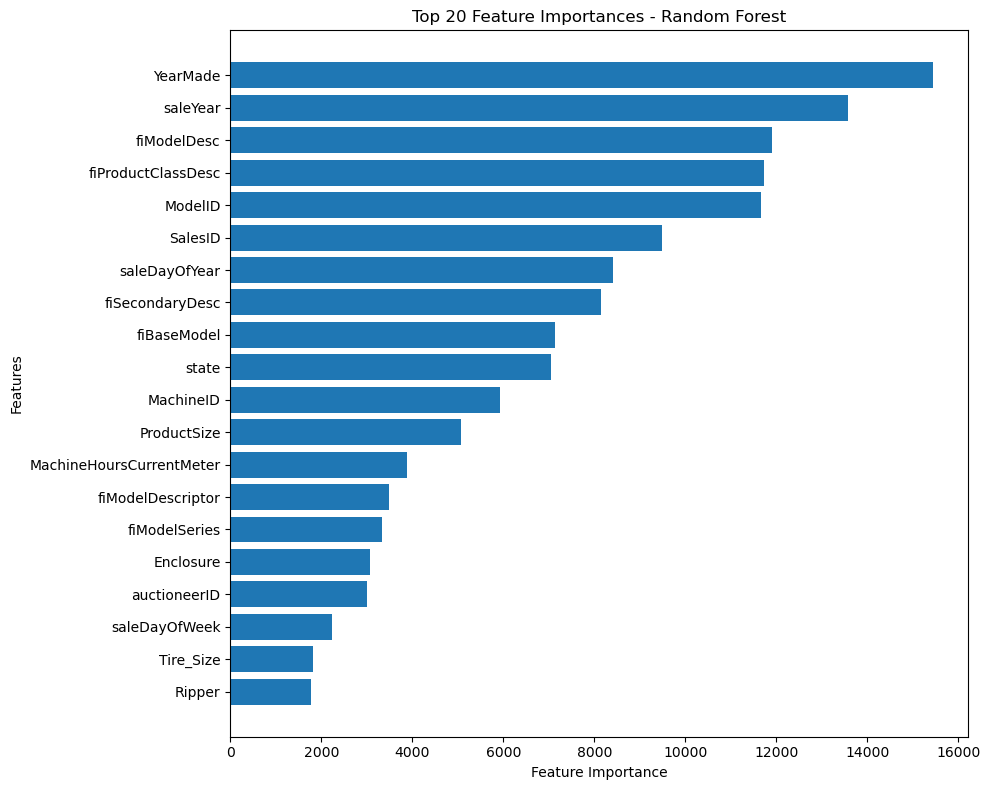

In [33]:
# Extract the fitted steps from the pipeline
date_extractor = bulldozer_lgb_pipeline.named_steps["date_extractor"]
imputer_encoder = bulldozer_lgb_pipeline.named_steps["imputer_and_encoder"]
rf_model = bulldozer_lgb_pipeline.named_steps["model"]

# Recreate the feature names after transformations
transformed_sample = imputer_encoder.transform(date_extractor.transform(X_train.head(1)))

# Extract feature names dynamically
if isinstance(transformed_sample, pd.DataFrame):
    feature_names = transformed_sample.columns.tolist()
else:
    # If it returns a numpy array, try getting feature names from the encoder if it saved them, 
    # or fallback to generic indices / input columns
    if hasattr(imputer_encoder, "get_feature_names_out"):
        feature_names = imputer_encoder.get_feature_names_out()
    else:
        feature_names = [f"feature_{i}" for i in range(rf_model.n_features_in_)]

# Create a DataFrame of feature importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display the top 20 most important features
print("--- Top 20 Most Important Features ---")
print(importance_df.head(20))

# 5. Plot the top 20 features
plt.figure(figsize=(10, 8))
plt.barh(importance_df["Feature"].head(20)[::-1], importance_df["Importance"].head(20)[::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Feature Importances - Random Forest")
plt.tight_layout()
# Save the figure as an image file
plt.savefig("feature_importance_rf.png", dpi=300)
plt.show()